# Libraries and dependencies

In [ ]:
# Firstly we need to install some libraries. They are commented because it is needed only the first run.

In [1]:
#!pip install tensorflow==2.10.0 tensorflow-gpu==2.10.0

In [2]:
#!pip install matplotlib opencv-python

In [3]:
#!pip list

In [1]:
import tensorflow as tf
import os

In [2]:
# Should help to avoid OOM errors
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Rename of images in folder

In [4]:
# This function was renaming the image and than saving to final folder
def rename_images(folder_path):
    # get all files to list in folder
    files = os.listdir(folder_path)
    count = 701
    for file_name in files:
        file_ext = os.path.splitext(file_name)[1]
        # Do not forget to change the new file name !
        new_file_name = f'Deep3_{count}{file_ext}'
        old_path = os.path.join(folder_path, file_name)
        new_path = os.path.join(folder_path, new_file_name)
        os.rename(old_path, new_path)
        count += 1

# actual path
folder_path = r'' # Add the path to the files
rename_images(folder_path)

# Load data

In [4]:
import numpy as np
from matplotlib import pyplot as plt

In [23]:
# data contains labels according to the folder
data = tf.keras.utils.image_dataset_from_directory('data', image_size=(128, 128))
class_name = data.class_names
print("Class names:", class_name)

Found 6300 files belonging to 2 classes.
Class names: ['Deepfake', 'Original']


# Scale and split of data

In [24]:
# Scale input to range (0, 1)
data = data.map(lambda x, y: (x/255, y))

# Shuffle Data
data = data.shuffle(buffer_size=len(data)) # buffer_size=len(data), seed=13

# Split Data
train_size = int(len(data) * 0.7)
val_size = int(len(data) * 0.2)
test_size = len(data) - train_size - val_size

train_data = data.take(train_size)
val_data = data.skip(train_size).take(val_size)
test_data = data.skip(train_size + val_size).take(test_size)

# Work with CNN

## Build of CNN

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.applications import VGG19 #VGG16, ResNet50, ResNet101
from tensorflow.keras import layers

In [26]:
base_model = VGG19(include_top=False, input_shape=(128,128,3)) # weights='imagenet'

In [27]:
# Freezing convolutional layer of VGG
for layer in base_model.layers:
    layer.trainable = False

In [28]:
model = Sequential([
    base_model,
    layers.Flatten(),   # Convert to 1D from 3D
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [29]:
model.compile('adam', loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 4, 4, 512)         20024384  
                                                                 
 flatten_1 (Flatten)         (None, 8192)              0         
                                                                 
 dense_2 (Dense)             (None, 64)                524352    
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 20,548,801
Trainable params: 524,417
Non-trainable params: 20,024,384
_________________________________________________________________


## Train of CNN

In [31]:
logdir = 'logs'

In [32]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [33]:
history = model.fit(train_data, validation_data=val_data, epochs=50, callbacks=[tensorboard_callback]) # 50 maybe

Epoch 1/50
137/137 [==============================] - 16s 98ms/step - loss: 0.5377 - accuracy: 0.7735 - val_loss: 0.4890 - val_accuracy: 0.7756
Epoch 2/50
137/137 [==============================] - 15s 100ms/step - loss: 0.5056 - accuracy: 0.7767 - val_loss: 0.4601 - val_accuracy: 0.7941
Epoch 3/50
137/137 [==============================] - 15s 97ms/step - loss: 0.4725 - accuracy: 0.7831 - val_loss: 0.4496 - val_accuracy: 0.7894
Epoch 4/50
137/137 [==============================] - 15s 97ms/step - loss: 0.4494 - accuracy: 0.7998 - val_loss: 0.4427 - val_accuracy: 0.7814
Epoch 5/50
137/137 [==============================] - 15s 98ms/step - loss: 0.4285 - accuracy: 0.8121 - val_loss: 0.4124 - val_accuracy: 0.8069
Epoch 6/50
137/137 [==============================] - 15s 97ms/step - loss: 0.4175 - accuracy: 0.8210 - val_loss: 0.4304 - val_accuracy: 0.8037
Epoch 7/50
137/137 [==============================] - 15s 98ms/step - loss: 0.4235 - accuracy: 0.8205 - val_loss: 0.4097 - val_accuracy

In [34]:
test_loss, test_acc = model.evaluate(test_data)
print('Test accuracy:', test_acc)

21/21 [==============================] - 3s 68ms/step - loss: 0.0523 - accuracy: 0.9970
Test accuracy: 0.9970238208770752


In [ ]:
# Next cell is for evaluation of model performance. Most of the time i was just using the model from Ram and do not need to load it but
# there is also possibilty to make evaluation from model in folder
# from tensorflow.keras.models import load_model
# new_model = load_model('models/vgg19_50_none.h5')

In [35]:
# This script is same for next cells. It takes image from folder, then normalize it and makes predictions. If it predicts that the image is
# original the counter increments. And at the end i am counting ratio according if i am trying to evaluate deepfakes or originals
# First for cycle is for LFW dataset and second for CelebA HQ dataset.
import cv2
import numpy as np
from PIL import Image

count = 0
for index in range(1, 101):
    img = Image.open(f'data/Deepfake/Deep1_{index}.jpg')

    if img is None:
        print(f"Failed to load images for index {index}")
        continue

    img = np.array(img, dtype='float32') / 255.0

    predictions = model.predict(np.expand_dims(img/255, 0))

    if predictions >= 0.5:
        count += 1 # Original

ratio1 = (100-count) / 100

print("Ratio of predicted deepfakes:", ratio1)

# Vgg16 none 1.0
# Vgg16 imagenet 1.0
# Vgg19 none 1.0
# Vgg19 imagenet 1.0
# ResNet50 none 1.0
# ResNet50 imagenet 1.0
# ResNet101 none 1.0
# ResNet101 imagenet 1.0

1/1 [==============================] - 0s 20ms/step
Ratio of predicted deepfakes: 1.0
Ratio of predicted deepfakes: 0.9928571428571429


In [36]:
count = 0
for index in range(1, 101):
    img = Image.open(f'data/Deepfake/Deep2_{index}.jpg')

    if img is None:
        print(f"Failed to load images for index {index}")
        continue

    img = np.array(img, dtype='float32') / 255.0

    predictions = model.predict(np.expand_dims(img, 0))

    if predictions >= 0.5:
        count += 1 # Original

ratio1 = (100-count) / 100

print("Ratio of predicted deepfakes:", ratio1)

# Vgg16 imagenet 0.87
# Vgg16 none 0.75
# Vgg19 imagenet 0.75
# Vgg19 none 0.65
# ResNet50 imagenet 0.92
# Resnet50 none 0.93
# ResNet101 imagenet 0.97
# ResNet101 none 0.96

1/1 [==============================] - 0s 23ms/step
Ratio of predicted deepfakes: 0.9871428571428571
Ratio of predicted deepfakes: 0.9885714285714285


In [37]:
count = 0
for index in range(1, 101):
    img = Image.open(f'data/Deepfake/Deep3_{index}.jpg')

    if img is None:
        print(f"Failed to load images for index {index}")
        continue

    img = np.array(img, dtype='float32') / 255.0

    predictions = model.predict(np.expand_dims(img, 0))

    if predictions >= 0.5:
        count += 1 # Original

ratio1 = (100-count) / 100
print("Ratio of predicted deepfakes:", ratio1)

# Vgg16 imagenet 0.91
# Vgg16 none 0.88
# Vgg19 imagenet 0.88
# Vgg19 none 0.71
# ResNet50 imagenet 0.99
# Resnet50 none 0.99
# ResNet101 imagenet 1.0
# ResNet101 none 1.0

1/1 [==============================] - 0s 20ms/step
Ratio of predicted deepfakes: 0.9957142857142857


In [38]:
import cv2
import numpy as np

count = 0
for index in range(1, 101):
    img = Image.open(f'data/Deepfake/Deep4_{index}.jpg')

    if img is None:
        print(f"Failed to load images for index {index}")
        continue

    img = np.array(img, dtype='float32') / 255.0

    predictions = model.predict(np.expand_dims(img, 0))

    if predictions >= 0.5:
        count += 1 # Original

ratio1 = (100-count) / 100

print("Ratio of predicted deepfakes:", ratio1)

# Vgg16 imagenet 0.88
# Vgg16 none 0.88
# Vgg19 imagenet 0.88
# Vgg19 none 0.82
# ResNet50 imagenet 0.96
# Resnet50 none 0.99
# ResNet101 imagenet 0.99
# ResNet101 none 0.99

1/1 [==============================] - 0s 30ms/step
Ratio of predicted deepfakes: 0.9985714285714286
Ratio of predicted deepfakes: 0.99


In [39]:
import cv2
import numpy as np

count = 0
for index in range(1, 101):
    img = Image.open(f'data/Original/Origin_{index}.jpg')

    if img is None:
        print(f"Failed to load images for index {index}")
        continue

    img = np.array(img, dtype='float32') / 255.0

    predictions = model.predict(np.expand_dims(img, 0))

    if predictions >= 0.5:
        count += 1 # Original

ratio1 = count / 100

print("Ratio of predicted originals:", ratio1)

# Vgg16 imagenet 0.38
# Vgg16 none 0.41
# Vgg19 imagenet 0.41
# Vgg19 none 0.57
# ResNet50 imagenet 0.06
# Resnet50 none 0.06
# ResNet101 imagenet 0.03
# ResNet101 none 0.05

1/1 [==============================] - 0s 30ms/step
Ratio of predicted deepfakes: 0.9928571428571429
Ratio of predicted deepfakes: 0.9957142857142857


# Visualization

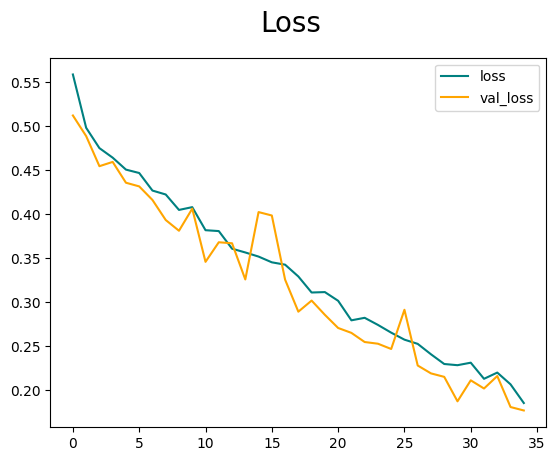

In [21]:
# Creation of graphs that are used in the thesis
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper right")
plt.show()

# Save loss plot as SVG
fig.savefig('loss_plot.svg')

# Save loss plot as PNG
fig.savefig('loss_plot.png')

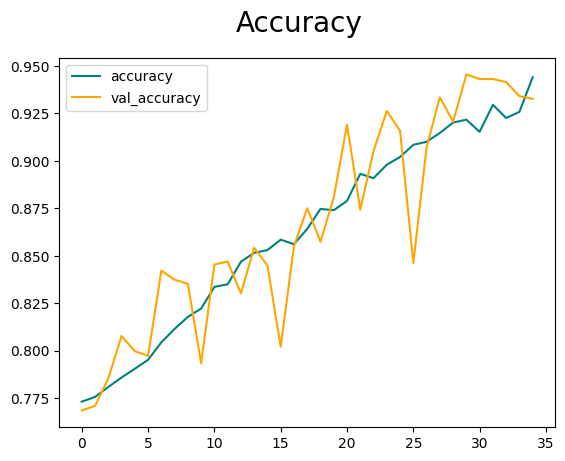

In [22]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# Save loss plot as SVG
fig.savefig('accuracy_plot.svg')

# Save loss plot as PNG
fig.savefig('accuracy_plot.png')

# Save the model

In [40]:
# Final saving of trained model
from tensorflow.keras.models import load_model
model.save(os.path.join('final_models','vgg19_50_none.h5')) # .h5 for keras models

# Comparision with BioID

In [17]:
# Here is version for more images at once
import numpy as np
from PIL import Image
deep_count = 0
origo_count = 0
for index in range(1,21):
    img = Image.open(f'bio/Deep1/Deep1_{index}.jpg')
    img = np.array(img, dtype='float32') / 255.0
    predict = model.predict(np.expand_dims(img, 0))
    prediction_index = np.argmax(predict)
    if predict > 0.5: 
        origo_count += 1
    else:
        deep_count += 1
print(origo_count, deep_count)

deep_count = 0
origo_count = 0
for index in range(1,21):
    img = Image.open(f'bio/Deep2/Deep2_{index}.jpg')
    img = np.array(img, dtype='float32') / 255.0
    predict = model.predict(np.expand_dims(img, 0))
    prediction_index = np.argmax(predict)
    if predict > 0.5: 
        origo_count += 1
    else:
        deep_count += 1
print(origo_count, deep_count)

deep_count = 0
origo_count = 0
for index in range(1,21):
    img = Image.open(f'bio/Deep3/Deep3_{index}.jpg')
    img = np.array(img, dtype='float32') / 255.0
    predict = model.predict(np.expand_dims(img, 0))
    prediction_index = np.argmax(predict)
    if predict > 0.5: 
        origo_count += 1
    else:
        deep_count += 1
print(origo_count, deep_count)

deep_count = 0
origo_count = 0
for index in range(1,21):
    img = Image.open(f'bio/Deep4/Deep4_{index}.jpg')
    img = np.array(img, dtype='float32') / 255.0
    predict = model.predict(np.expand_dims(img, 0))
    prediction_index = np.argmax(predict)
    if predict > 0.5: 
        origo_count += 1
    else:
        deep_count += 1
print(origo_count, deep_count)

deep_count = 0
origo_count = 0
for index in range(1,21):
    img = Image.open(f'bio/Origin/Origin_{index}.jpg')
    img = np.array(img, dtype='float32') / 255.0
    predict = model.predict(np.expand_dims(img, 0))
    prediction_index = np.argmax(predict)
    if predict > 0.5: 
        origo_count += 1
    else:
        deep_count += 1
print(origo_count, deep_count)

# Deep1 3 17 - 85 %
# Deep2 2 18 - 90 %
# Deep3 2 18 - 90 %
# Deep4 3 17 - 85 %
# Origin 8 12 - 40 % - 78 %

770
1/1 [==============================] - 0s 37ms/step
803
1/1 [==============================] - 0s 7ms/step
811
1/1 [==============================] - 0s 18ms/step
867
1/1 [==============================] - 0s 16ms/step
890
1/1 [==============================] - 0s 18ms/step
902
1/1 [==============================] - 0s 5ms/step
1011
1/1 [==============================] - 0s 9ms/step
1013
1/1 [==============================] - 0s 23ms/step
1024
1/1 [==============================] - 0s 18ms/step
1076
1/1 [==============================] - 0s 17ms/step
1089
1/1 [==============================] - 0s 18ms/step
1129
1/1 [==============================] - 0s 18ms/step
1157
1/1 [==============================] - 0s 18ms/step
1168
1/1 [==============================] - 0s 17ms/step
1206
1/1 [==============================] - 0s 16ms/step
1253
1/1 [==============================] - 0s 18ms/step
1265
1/1 [==============================] - 0s 24ms/step
1322
1/1 [==============================